# ReadyNest Messenger — Fake Chat App (Colab Demo)

A self-contained chat app (Flask + Flask-SocketIO + SQLite) with real-time messaging,
seeded fake users, and 30 days of fake message history — built so you can run it
entirely inside Colab and then do the data analytics part yourself against the
resulting `readynest.db` SQLite file.

Run the cells top to bottom. The ngrok cell will print a public URL you can open —
log in as any seeded user (password: `password123`).

In [1]:
!pip install -q flask flask-socketio flask-sqlalchemy pyngrok python-socketio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00


In [2]:
%%writefile app.py
"""
ReadyNest Messenger - Fake/Demo Chat App
Runs standalone: Flask + Flask-SocketIO + SQLite (no MongoDB/Node needed).
Built to run inside Google Colab via ngrok tunnel.

Seeds realistic fake users + 30 days of message history on first run,
so the SQLite file (readynest.db) is immediately ready for the
data analytics part (query it with pandas / SQL).
"""
import os
import random
from datetime import datetime, timedelta

from flask import Flask, request, session, redirect, url_for, render_template_string, jsonify
from flask_sqlalchemy import SQLAlchemy
from flask_socketio import SocketIO, join_room, emit

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

app = Flask(__name__)
app.config['SECRET_KEY'] = 'readynest-fake-demo-secret'
app.config['SQLALCHEMY_DATABASE_URI'] = f"sqlite:///{os.path.join(BASE_DIR, 'readynest.db')}"
app.config['SQLALCHEMY_TRACK_MODIFICATIONS'] = False

db = SQLAlchemy(app)
socketio = SocketIO(app, cors_allowed_origins="*", async_mode="threading")

# ---------------------------------------------------------------- MODELS ---

class User(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    name = db.Column(db.String(80), nullable=False)
    email = db.Column(db.String(120), unique=True, nullable=False)
    password = db.Column(db.String(120), nullable=False)  # plain text: fake demo only
    is_blocked = db.Column(db.Boolean, default=False)
    created_at = db.Column(db.DateTime, default=datetime.utcnow)


class Message(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    sender_id = db.Column(db.Integer, db.ForeignKey('user.id'), nullable=False)
    chat_id = db.Column(db.String(80), nullable=False)  # e.g. "dm-1-2" or "group-design"
    content = db.Column(db.Text, nullable=False)
    created_at = db.Column(db.DateTime, default=datetime.utcnow)

    sender = db.relationship('User')


# Fixed rooms for this fake demo: a few 1-1 DMs + a couple of group chats
CHAT_ROOMS = ['dm-general', 'group-design', 'group-project']
SAMPLE_LINES = [
    "Hey! How are you?", "I'm good, working on the messenger project.",
    "Great! Don't forget to add file sharing feature.", "Sure, I'll complete it today.",
    "Can you review my PR?", "Sounds good, checking now.", "Meeting at 5?",
    "Yep, see you then.", "Thanks for the update!", "No problem 👍",
    "Let's connect later.", "Okay, sounds good.",
]
NAMES = [
    'John Doe', 'Sneha Verma', 'Rahul Sharma', 'Pooja Iyer', 'Aman Singh',
    'Mehak Gupta', 'Rohit Malhotra', 'Ananya Rao', 'Karan Mehta', 'Divya Nair',
]


def seed_if_empty():
    if User.query.first():
        return
    users = []
    for n in NAMES:
        u = User(
            name=n,
            email=f"{n.lower().replace(' ', '.')}@readynest.in",
            password="password123",
        )
        db.session.add(u)
        users.append(u)
    db.session.commit()

    # 30 days of fake message history, upward trend + weekend dip,
    # same shape the analytics module expects (sender + createdAt).
    for day_offset in range(29, -1, -1):
        day = datetime.utcnow().replace(hour=0, minute=0, second=0, microsecond=0) - timedelta(days=day_offset)
        is_weekend = day.weekday() >= 5
        base = 15 + (29 - day_offset) * 1.2
        count = max(3, int(base * (0.6 if is_weekend else 1) + random.randint(-5, 5)))
        for _ in range(count):
            sender = random.choice(users)
            sent_at = day + timedelta(hours=random.randint(7, 22), minutes=random.randint(0, 59))
            msg = Message(
                sender_id=sender.id,
                chat_id=random.choice(CHAT_ROOMS),
                content=random.choice(SAMPLE_LINES),
                created_at=sent_at,
            )
            db.session.add(msg)
    db.session.commit()
    print(f"Seeded {len(users)} users and {Message.query.count()} messages.")


# ----------------------------------------------------------------- AUTH ---

LOGIN_HTML = """
<!doctype html><html><head><title>ReadyNest Messenger - Login</title>
<style>
body{font-family:system-ui;background:#0d1b2e;color:#fff;display:flex;align-items:center;justify-content:center;height:100vh;margin:0}
.card{background:#13253d;padding:32px;border-radius:12px;width:320px}
h2{margin-top:0;color:#1fae86}
input{width:100%;padding:10px;margin:6px 0;border-radius:6px;border:1px solid #ffffff30;background:#0d1b2e;color:#fff;box-sizing:border-box}
button{width:100%;padding:10px;margin-top:10px;border:none;border-radius:6px;background:#1fae86;color:#fff;font-weight:600;cursor:pointer}
a{color:#1fae86}
.err{color:#ff8080;font-size:13px}
</style></head><body>
<div class="card">
<h2>ReadyNest Messenger</h2>
<p style="color:#ffffff80;font-size:13px">Demo login — pick any seeded user, password is <code>password123</code></p>
{% if error %}<p class="err">{{ error }}</p>{% endif %}
<form method="POST">
<input name="email" placeholder="Email (e.g. john.doe@readynest.in)" required>
<input name="password" type="password" placeholder="Password" required>
<button type="submit">Log in</button>
</form>
<p style="font-size:12px;color:#ffffff60">Seeded users: {{ users }}</p>
</div></body></html>
"""

CHAT_HTML = """
<!doctype html><html><head><title>ReadyNest Messenger</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/socket.io/4.7.5/socket.io.min.js"></script>
<style>
body{font-family:system-ui;margin:0;background:#0d1b2e;color:#fff;display:flex;height:100vh}
.sidebar{width:220px;background:#13253d;padding:16px;box-sizing:border-box}
.sidebar h3{color:#1fae86;font-size:13px;text-transform:uppercase}
.room{padding:8px;border-radius:6px;cursor:pointer;margin-bottom:4px}
.room:hover,.room.active{background:#1fae8630}
.main{flex:1;display:flex;flex-direction:column}
.header{padding:14px 20px;background:#13253d;display:flex;justify-content:space-between;align-items:center}
.messages{flex:1;padding:20px;overflow-y:auto;display:flex;flex-direction:column;gap:10px}
.msg{max-width:60%;padding:8px 12px;border-radius:10px;background:#13253d}
.msg.mine{align-self:flex-end;background:#1fae86;color:#0d1b2e}
.msg .who{font-size:11px;opacity:.7;margin-bottom:2px}
.inputbar{display:flex;padding:14px;background:#13253d;gap:8px}
.inputbar input{flex:1;padding:10px;border-radius:6px;border:none;background:#0d1b2e;color:#fff}
.inputbar button{padding:10px 16px;border:none;border-radius:6px;background:#1fae86;color:#0d1b2e;font-weight:600;cursor:pointer}
.logout{font-size:12px;color:#ffffff80}
</style></head><body>
<div class="sidebar">
  <h3>Chats</h3>
  {% for room in rooms %}
  <div class="room" data-room="{{ room }}" onclick="switchRoom('{{ room }}')">{{ room }}</div>
  {% endfor %}
</div>
<div class="main">
  <div class="header">
    <strong id="roomTitle">dm-general</strong>
    <span>{{ user.name }} &nbsp; <a class="logout" href="/logout">Logout</a></span>
  </div>
  <div class="messages" id="messages"></div>
  <div class="inputbar">
    <input id="msgInput" placeholder="Type a message..." onkeydown="if(event.key==='Enter')sendMsg()">
    <button onclick="sendMsg()">Send</button>
  </div>
</div>
<script>
const socket = io();
const myId = {{ user.id }};
let currentRoom = "dm-general";

function renderMsg(m) {
  const div = document.createElement('div');
  div.className = 'msg' + (m.sender_id === myId ? ' mine' : '');
  div.innerHTML = `<div class="who">${m.sender_name}</div>${m.content}`;
  document.getElementById('messages').appendChild(div);
  document.getElementById('messages').scrollTop = 1e9;
}

function loadHistory(room) {
  document.getElementById('messages').innerHTML = '';
  fetch('/api/history/' + room).then(r => r.json()).then(msgs => msgs.forEach(renderMsg));
}

function switchRoom(room) {
  socket.emit('leave', { room: currentRoom });
  currentRoom = room;
  document.getElementById('roomTitle').innerText = room;
  socket.emit('join', { room });
  loadHistory(room);
}

function sendMsg() {
  const input = document.getElementById('msgInput');
  if (!input.value.trim()) return;
  socket.emit('send_message', { room: currentRoom, content: input.value });
  input.value = '';
}

socket.on('connect', () => socket.emit('join', { room: currentRoom }));
socket.on('receive_message', (m) => { if (m.chat_id === currentRoom) renderMsg(m); });
loadHistory(currentRoom);
</script>
</body></html>
"""


@app.route('/', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        email = request.form['email'].strip().lower()
        password = request.form['password']
        user = User.query.filter_by(email=email, password=password).first()
        if not user:
            names = ', '.join(u.email for u in User.query.limit(5))
            return render_template_string(LOGIN_HTML, error='Invalid email or password.', users=names)
        session['user_id'] = user.id
        return redirect(url_for('chat'))
    names = ', '.join(u.email for u in User.query.limit(5))
    return render_template_string(LOGIN_HTML, error=None, users=names)


@app.route('/logout')
def logout():
    session.clear()
    return redirect(url_for('login'))


@app.route('/chat')
def chat():
    if 'user_id' not in session:
        return redirect(url_for('login'))
    user = User.query.get(session['user_id'])
    return render_template_string(CHAT_HTML, user=user, rooms=CHAT_ROOMS)


@app.route('/api/history/<room>')
def history(room):
    msgs = (Message.query.filter_by(chat_id=room)
            .order_by(Message.created_at.asc()).limit(200).all())
    return jsonify([
        {
            'sender_id': m.sender_id,
            'sender_name': m.sender.name,
            'content': m.content,
            'created_at': m.created_at.isoformat(),
            'chat_id': m.chat_id,
        }
        for m in msgs
    ])


# -------------------------------------------------------------- SOCKETS ---

@socketio.on('join')
def on_join(data):
    join_room(data['room'])


@socketio.on('leave')
def on_leave(data):
    from flask_socketio import leave_room
    leave_room(data['room'])


@socketio.on('send_message')
def on_send_message(data):
    user = User.query.get(session.get('user_id'))
    if not user:
        return
    msg = Message(sender_id=user.id, chat_id=data['room'], content=data['content'])
    db.session.add(msg)
    db.session.commit()
    emit('receive_message', {
        'sender_id': user.id,
        'sender_name': user.name,
        'content': msg.content,
        'created_at': msg.created_at.isoformat(),
        'chat_id': msg.chat_id,
    }, room=data['room'])


with app.app_context():
    db.create_all()
    seed_if_empty()

if __name__ == '__main__':
    socketio.run(app, host='0.0.0.0', port=5000, allow_unsafe_werkzeug=True)

Writing app.py


### (Optional) Add your ngrok authtoken
Free account at https://dashboard.ngrok.com/get-started/your-authtoken — without this,
ngrok tunnels are short-lived / rate-limited but usually still work for a quick demo.

In [3]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3Gud3t3y02XALBWhlObfIvjIAmK_3hZKEDBYThu9mwmAbwamw"  # paste your token here (optional but recommended)
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)

In [4]:
import threading
import time
import app as chatapp

def run_app():
    chatapp.socketio.run(chatapp.app, host='0.0.0.0', port=5000, allow_unsafe_werkzeug=True)

thread = threading.Thread(target=run_app, daemon=True)
thread.start()
time.sleep(3)

public_url = ngrok.connect(5000)
print('Chat app is live at:', public_url)
print('Log in with any seeded user, e.g. john.doe@readynest.in / password123')

Seeded 10 users and 824 messages.
 * Serving Flask app 'app'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


Chat app is live at: NgrokTunnel: "https://cannabis-clapped-disperser.ngrok-free.dev" -> "http://localhost:5000"
Log in with any seeded user, e.g. john.doe@readynest.in / password123


In [5]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('readynest.db')
users_df = pd.read_sql_query('SELECT * FROM user', conn)
messages_df = pd.read_sql_query('SELECT * FROM message', conn)

print(users_df.shape, messages_df.shape)
messages_df.head()

(10, 6) (824, 5)


,id,sender_id,chat_id,content,created_at
0,1,4,group-project,"I'm good, working on the messenger project.",2026-06-28 14:38:00.000000
1,2,10,dm-general,"Yep, see you then.",2026-06-28 08:27:00.000000
2,3,1,group-project,"Okay, sounds good.",2026-06-28 16:18:00.000000
3,4,9,group-design,"Sure, I'll complete it today.",2026-06-28 12:34:00.000000
4,5,9,dm-general,"Okay, sounds good.",2026-06-28 08:29:00.000000


### Seeded login accounts
All use password `password123`. A few: `john.doe@readynest.in`, `sneha.verma@readynest.in`,
`rahul.sharma@readynest.in`, `aman.singh@readynest.in` — open the app in two browser tabs
logged in as different users to see real-time messaging work.

Rooms available: `dm-general`, `group-design`, `group-project`.

## Now: the data analytics part
The chat app writes everything to `readynest.db` (SQLite) — `User(id, name, email,
is_blocked, created_at)` and `Message(id, sender_id, chat_id, content, created_at)`.
Query it directly with pandas below, or export to CSV and build your own charts,
DAU counts, most-active-user leaderboard, and trend prediction from scratch.

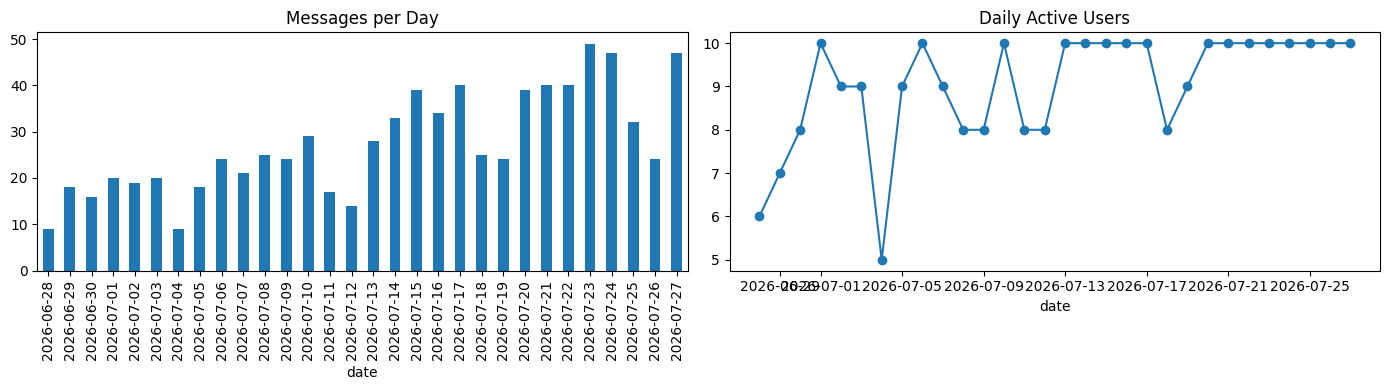

In [6]:
messages_df['created_at'] = pd.to_datetime(messages_df['created_at'])
messages_df['date'] = messages_df['created_at'].dt.date

messages_per_day = messages_df.groupby('date').size()
dau = messages_df.groupby('date')['sender_id'].nunique()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
messages_per_day.plot(kind='bar', ax=axes[0], title='Messages per Day')
dau.plot(kind='line', ax=axes[1], title='Daily Active Users', marker='o')
plt.tight_layout()
plt.show()

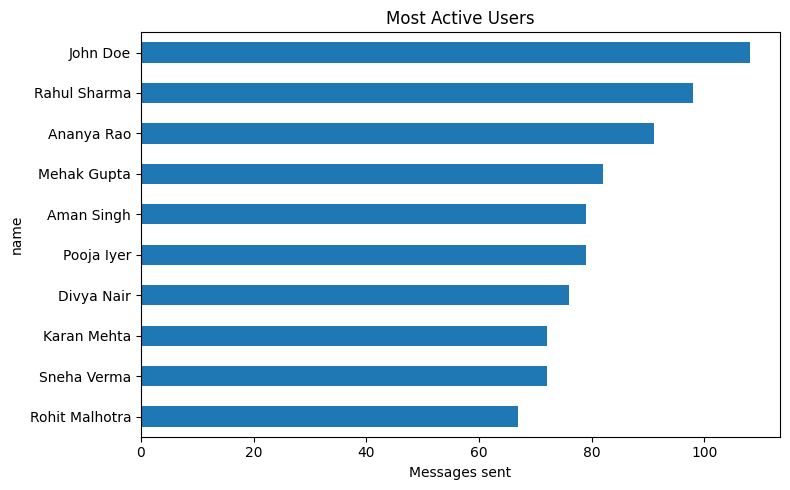

In [7]:
leaderboard = (
    messages_df.merge(users_df, left_on='sender_id', right_on='id')
    .groupby('name')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

leaderboard.plot(kind='barh', figsize=(8,5), title='Most Active Users').invert_yaxis()
plt.xlabel('Messages sent')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


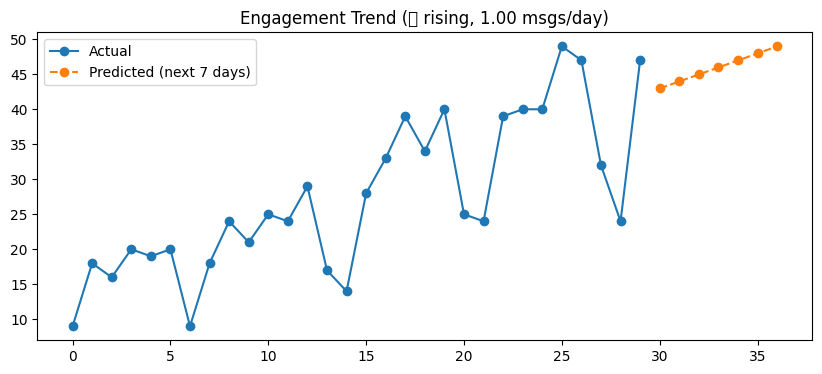

In [8]:
import numpy as np

daily = messages_per_day.reset_index()
daily.columns = ['date', 'messages']
daily['day_num'] = range(len(daily))

# fit a straight line: messages = slope*day + intercept
slope, intercept = np.polyfit(daily['day_num'], daily['messages'], 1)

future_days = np.arange(len(daily), len(daily) + 7)
predicted = slope * future_days + intercept

plt.figure(figsize=(10,4))
plt.plot(daily['day_num'], daily['messages'], label='Actual', marker='o')
plt.plot(future_days, predicted, label='Predicted (next 7 days)', linestyle='--', marker='o')
plt.title(f"Engagement Trend ({'📈 rising' if slope>0 else '📉 falling'}, {slope:.2f} msgs/day)")
plt.legend()
plt.show()

In [9]:
import random
from datetime import datetime, timedelta

with chatapp.app.app_context():
    # wipe existing data
    chatapp.Message.query.delete()
    chatapp.User.query.delete()
    chatapp.db.session.commit()

    # bigger name pool — 50 users
    first_names = ['Aarav','Vivaan','Aditya','Vihaan','Arjun','Sai','Reyansh','Ayaan','Krishna','Ishaan',
                   'Ananya','Diya','Aadhya','Saanvi','Myra','Anika','Pari','Riya','Sara','Isha',
                   'Karan','Rohit','Nikhil','Yash','Dev','Aman','Rahul','Varun','Aryan','Kunal',
                   'Priya','Neha','Pooja','Kavya','Meera','Shreya','Tanya','Nisha','Sneha','Aditi',
                   'Rohan','Gaurav','Manish','Suresh','Vikram','Akash','Deepak','Sameer','Harsh','Naveen']
    last_names = ['Sharma','Verma','Iyer','Singh','Gupta','Malhotra','Rao','Mehta','Nair','Joshi',
                  'Kapoor','Reddy','Patel','Chopra','Bhat','Menon','Pillai','Chatterjee','Das','Bose']

    users = []
    for i in range(50):
        fn = first_names[i % len(first_names)]
        ln = last_names[i % len(last_names)]
        name = f"{fn} {ln}"
        u = chatapp.User(
            name=name,
            email=f"{fn.lower()}.{ln.lower()}{i}@readynest.in",
            password="password123",
        )
        chatapp.db.session.add(u)
        users.append(u)
    chatapp.db.session.commit()

    # reseed 30 days of messages across all 50 users
    for day_offset in range(29, -1, -1):
        day = datetime.utcnow().replace(hour=0, minute=0, second=0, microsecond=0) - timedelta(days=day_offset)
        is_weekend = day.weekday() >= 5
        base = 40 + (29 - day_offset) * 2.5   # scaled up for 50 users
        count = max(10, int(base * (0.6 if is_weekend else 1) + random.randint(-8, 8)))
        for _ in range(count):
            sender = random.choice(users)
            sent_at = day + timedelta(hours=random.randint(7, 22), minutes=random.randint(0, 59))
            msg = chatapp.Message(
                sender_id=sender.id,
                chat_id=random.choice(chatapp.CHAT_ROOMS),
                content=random.choice(chatapp.SAMPLE_LINES),
                created_at=sent_at,
            )
            chatapp.db.session.add(msg)
    chatapp.db.session.commit()

    print(f"Now have {chatapp.User.query.count()} users and {chatapp.Message.query.count()} messages.")

/tmp/ipykernel_1736/660396647.py:35: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  day = datetime.utcnow().replace(hour=0, minute=0, second=0, microsecond=0) - timedelta(days=day_offset)


Now have 50 users and 2000 messages.


In [10]:
conn = sqlite3.connect('readynest.db')
users_df = pd.read_sql_query('SELECT * FROM user', conn)
messages_df = pd.read_sql_query('SELECT * FROM message', conn)

users_df.to_csv('users_export.csv', index=False)
messages_df.to_csv('messages_export.csv', index=False)

from google.colab import files
files.download('users_export.csv')
files.download('messages_export.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>